In [ ]:
import os
import sys

# --- Configuration ---
REPO_URL = "https://github.com/NVlabs/stylegan3.git"
REPO_DIR = "stylegan3"
MODEL_URL = "https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan3/versions/1/files/stylegan3-t-ffhq-1024x1024.pkl"
MODEL_FILENAME = "stylegan3-t-ffhq-1024x1024.pkl"
MODEL_DIR = "."  # current directory

# --- 1. Clone StyleGAN3 repository if not already present ---
if not os.path.exists(REPO_DIR):
    print(f"Cloning StyleGAN3 from {REPO_URL}...")
    os.system(f"git clone {REPO_URL}")

# --- 2. Add StyleGAN3 to Python path for module access ---
repo_path = os.path.abspath(REPO_DIR)
if repo_path not in sys.path:
    sys.path.append(repo_path)

# --- 3. Install required Python packages ---
required_packages = [
    "torchvision", "pillow", "tqdm", "ninja",
    "imageio", "imageio-ffmpeg", "opencv-python"
]
print("Installing required packages...")
os.system(f"pip install {' '.join(required_packages)}")

# --- 4. Download pretrained StyleGAN3 model if not present ---
model_path = os.path.join(MODEL_DIR, MODEL_FILENAME)
if not os.path.exists(model_path):
    print(f"Downloading pretrained model from {MODEL_URL}...")
    os.system(f"wget {MODEL_URL} -O {model_path}")
else:
    print(f"Pretrained model already exists at {model_path}")


Using device: cuda
Setting up PyTorch plugin "bias_act_plugin"... 

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.
Setting up PyTorch plugin "filtered_lrelu_plugin"... 

/usr/local/lib/python3.11/dist-packages/torch/utils/cpp_extension.py:2059: UserWarning: TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'].
  warnings.warn(


Done.


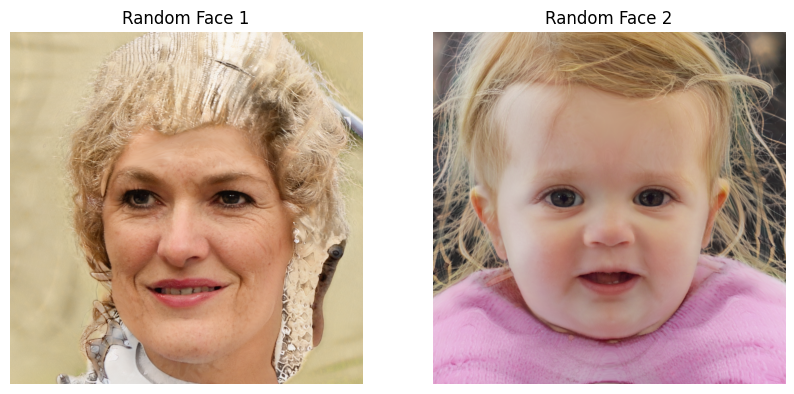

In [5]:
# --- 5. Import necessary libraries ---
import pickle
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt

# --- 6. Configuration ---
MODEL_FILENAME = "stylegan3-t-ffhq-1024x1024.pkl"
SEED = 128
NUM_IMAGES = 2
OUTPUT_PREFIX = "generated_face"

# --- 7. Set device (GPU if available, else CPU) ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] Using device: {device}")

# --- 8. Load the pretrained StyleGAN3 model ---
print(f"[INFO] Loading model from {MODEL_FILENAME}...")
with open(MODEL_FILENAME, "rb") as f:
    G = pickle.load(f)['G_ema'].to(device)

# Uncomment below to use the 256x256 model instead:
# with open("stylegan3-t-ffhqu-256x256.pkl", "rb") as f:
#     G = pickle.load(f)['G_ema'].to(device)

G.eval()
for param in G.parameters():
    param.requires_grad = False

# --- 9. Set random seed for reproducibility ---
torch.manual_seed(SEED)

# --- 10. Helper function to generate image from latent vector ---
def generate_face(generator, latent_vector):
    with torch.no_grad():
        image_tensor = generator(latent_vector, None)
    image_tensor = (image_tensor.clamp(-1, 1) + 1) * 127.5  # Scale to [0, 255]
    image_array = image_tensor.permute(0, 2, 3, 1)[0].cpu().numpy().astype(np.uint8)
    return image_array

# --- 11. Generate and save random faces ---
print(f"[INFO] Generating {NUM_IMAGES} face(s)...")
generated_images = []
for i in range(NUM_IMAGES):
    z = torch.randn(1, G.z_dim).to(device)
    img = generate_face(G, z)
    filename = f"{OUTPUT_PREFIX}_{i+1}.png"
    cv2.imwrite(filename, cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    generated_images.append(img)
    print(f"[INFO] Saved image: {filename}")

# --- 12. Display the generated images side-by-side ---
plt.figure(figsize=(5 * NUM_IMAGES, 5))
for i, img in enumerate(generated_images):
    plt.subplot(1, NUM_IMAGES, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Random Face {i+1}", fontsize=12)
plt.tight_layout()
plt.show()


## Question 2

In [ ]:
# --- 1. Setup and Clone StyleGAN3 repo if not already present ---
import os
import sys

REPO_URL = "https://github.com/NVlabs/stylegan3.git"
REPO_DIR = "stylegan3"
MODEL_URL = "https://api.ngc.nvidia.com/v2/models/nvidia/research/stylegan3/versions/1/files/stylegan3-t-ffhq-1024x1024.pkl"
MODEL_FILENAME = "stylegan3-t-ffhq-1024x1024.pkl"
GIF_FILENAME = "2_person_face_transition.gif"
NUM_INTERP_STEPS = 50
SEED = 128

# Clone the repo
if not os.path.exists(REPO_DIR):
    print("[INFO] Cloning StyleGAN3 repository...")
    os.system(f"git clone {REPO_URL}")

# Add repo to system path
sys.path.append(f"/content/{REPO_DIR}")

# --- 2. Install required libraries ---
print("[INFO] Installing required libraries...")
os.system("pip install torch torchvision numpy scipy pillow tqdm ninja imageio imageio-ffmpeg opencv-python matplotlib")

# --- 3. Download pretrained model if not already present ---
if not os.path.exists(MODEL_FILENAME):
    print(f"[INFO] Downloading pretrained model: {MODEL_FILENAME}...")
    os.system(f"wget {MODEL_URL} -O {MODEL_FILENAME}")

# --- 4. Import required packages ---
import pickle
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import imageio
from tqdm import tqdm

# --- 5. Set device ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[INFO] Using device: {device}")

# --- 6. Load the pretrained StyleGAN3 model ---
print(f"[INFO] Loading model from: {MODEL_FILENAME}")
with open(MODEL_FILENAME, "rb") as f:
    G = pickle.load(f)["G_ema"].to(device)

G.eval()
for param in G.parameters():
    param.requires_grad = False

# --- 7. Set seed for reproducibility ---
torch.manual_seed(SEED)

# --- 8. Generate two random latent vectors ---
z1 = torch.randn(1, G.z_dim).to(device)
z2 = torch.randn(1, G.z_dim).to(device)

# --- 9. Define helper function to generate image from latent vector ---
def generate_face(generator, z):
    with torch.no_grad():
        img = generator(z, None)
    img = (img.clamp(-1, 1) + 1) * 127.5
    img = img.permute(0, 2, 3, 1)[0].cpu().numpy().astype(np.uint8)
    return img

# --- 10. Generate and save two faces ---
print("[INFO] Generating two random faces...")
faces = []
for i, z in enumerate([z1, z2]):
    img = generate_face(G, z)
    cv2.imwrite(f"new_generated_face_{i+1}.png", cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
    faces.append(img)

# --- 11. Display the two faces side-by-side ---
plt.figure(figsize=(10, 5))
for i, img in enumerate(faces):
    plt.subplot(1, 2, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Face {i+1}", fontsize=12)
plt.tight_layout()
plt.show()

# --- 12. Generate interpolation frames ---
print(f"[INFO] Generating {NUM_INTERP_STEPS} interpolation frames...")
interp_frames = []
for i in tqdm(range(NUM_INTERP_STEPS), desc="Interpolating..."):
    alpha = i / (NUM_INTERP_STEPS - 1)
    z_interp = (1 - alpha) * z1 + alpha * z2
    img = generate_face(G, z_interp)
    interp_frames.append(img)

# --- 13. Save frames as GIF ---
imageio.mimsave(GIF_FILENAME, interp_frames, duration=0.1)
print(f"[INFO] Saved interpolation GIF: {GIF_FILENAME}")
